# 00 — Build public NEON sample

**Why this notebook exists**

Solafune competition imagery and labels are **private** — they cannot be redistributed or committed to a public repo. This notebook builds a **publishable alternate** in the same Solafune-shaped layout (RGB tiles + polygon JSON) so we can:

- Run and test the pipeline without competition credentials
- Share the project publicly with a real tree-crown sample
- Keep competition data local-only under `data/` when `dataset.active: competition`

**What it does**

1. Download the public [NeonTreeEvaluation crown subset](https://zenodo.org/records/15354422) (~11 MB) into `data/public_sample/raw/data.zip`
2. Convert instance masks → Solafune-style `individual_tree` polygons
3. Write train/eval PNGs + JSON under `data/public_sample/` (PNGs padded to a multiple of 16 so U-Net skip connections work; keep `train.image_size` a multiple of 16 too)

Requires `dataset.active: public` in `config.yaml`. For the real Solafune set, set `active: competition` and skip this notebook (use local competition files instead).

Note: the public sample has no `group_of_trees` class — that remains competition-only.


In [1]:
import os
import sys
from pathlib import Path

print("resolving project root…")
from dotenv import load_dotenv

load_dotenv()
_start = Path(os.getenv("PROJECT_ROOT") or Path.cwd()).resolve()
root = next(p for p in [_start, *_start.parents] if (p / "config.yaml").exists())
sys.path[:0] = [str(root), str(root / "src")]
print("root:", root)

# Config/helpers pull torch — first import can be slow on an external volume
print("loading config…")
from src.utils.config import Config
from src.utils.dataset_source import get_active_source, list_download_files, resolve_download_dir
from src.utils.helpers import c, p, t

config = Config.load(root=root)
source = get_active_source(config)
print("ready")


resolving project root…
root: /Volumes/Colibri/Projects/cap6415-tree-canopy-detection
loading config…

ready


In [2]:
# Show configured paths before download / convert
#config.show()

p("Active source", source["key"])
p("Catalog", source.get("catalog"))
download_dir = resolve_download_dir(config, source)
p("Download dir", download_dir)
for f in list_download_files(source):
    dest = download_dir / f["filename"]
    p("Zip file", dest)
    p("Zip url", f.get("url"))
    p("Zip exists", dest.exists())


Active source: public
Catalog: https://zenodo.org/records/15354422
Download dir: /Volumes/Colibri/Projects/cap6415-tree-canopy-detection/data/public_sample/raw
Zip file: /Volumes/Colibri/Projects/cap6415-tree-canopy-detection/data/public_sample/raw/data.zip
Zip url: https://zenodo.org/api/records/15354422/files/data.zip/content
Zip exists: 1


In [3]:
from src.data.neon_to_solafune import build_public_sample
from src.utils.helpers import init_notebook

init_notebook(config.train.seed)

=== init_notebook ===
Done


In [4]:
if source["key"] != "public":
    p(
        "Skip",
        "Set dataset.active: public in config.yaml to build the NEON sample",
        color1=c.ORANGE,
    )
    summary = None
else:
    # force=True rebuilds images/JSON even if they already exist
    summary = build_public_sample(config, force=False)
    summary


=== Build public NEON sample ===
=== Dataset download ===
Active source: public — NeonTreeEvaluation crown subset (Solafune-shaped)
Catalog: https://zenodo.org/records/15354422
Download dir: /Volumes/Colibri/Projects/cap6415-tree-canopy-detection/data/public_sample/raw
Notes: Public individual-tree crowns (~11 MB). Converted by notebook 00 into Solafune JSON under data/public_sample/. Not a drop-in for group_of_trees.
skip (exists): data.zip
Done: downloaded=0 skipped=1 manual=0
extract: already present
converted: neon_2018_SJER_3_252000_4106000_image_234.png (train) trees=1 400x400
converted: neon_2018_SJER_3_254000_4108000_image_700.png (train) trees=4 400x400
converted: neon_2018_TEAK_3_318000_4107000_image_718.png (train) trees=1 400x400
converted: neon_ABBY_063_2019.png (train) trees=57 400x400
converted: neon_ABBY_076_2019.png (train) trees=103 400x400
converted: neon_BART_050_2019.png (train) trees=51 400x400
converted: neon_BONA_005_2019.png (train) trees=59 400x400
converted: 

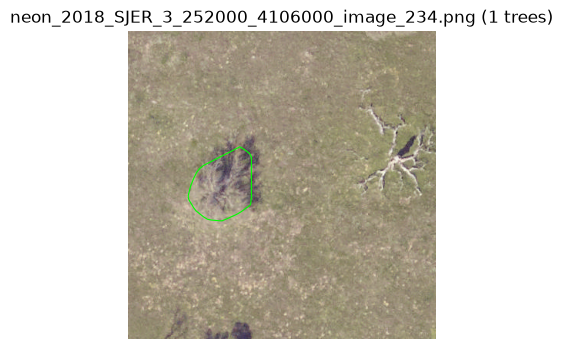

=== Next ===
Run 01_preflight_check.ipynb


In [5]:
if summary:
    import json

    import matplotlib.pyplot as plt
    import numpy as np
    from PIL import Image

    ann = json.loads(Path(summary["annotations"]).read_text())
    rec = ann["images"][0]
    img_path = Path(summary["train_dir"]) / rec["file_name"]
    img = np.array(Image.open(img_path))

    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(img)
    for a in rec["annotations"]:
        seg = a["segmentation"]
        xs = seg[0::2]
        ys = seg[1::2]
        ax.plot(xs + [xs[0]], ys + [ys[0]], color="lime", linewidth=0.8)
    ax.set_title(f"{rec['file_name']} ({len(rec['annotations'])} trees)")
    ax.axis("off")
    plt.show()
    t("Next")
    p("", "Run 01_preflight_check.ipynb")
